## Google Search Trend Analysis using Python

- Installing and import libraries 

In [1]:
! pip install pytrends matplotlib seaborn plotly pandas


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [2]:
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Connect to Google Trends

In [53]:
pytrends = TrendReq(hl='en-US' , tz=360)         # tz=330 for India
keywords =  "Data Analyst" 

### To Data Request

In [54]:
pytrends.build_payload([keywords], cat=0, timeframe='today 12-m', geo='', gprop='')

### Time-wise Interest Deduction

In [55]:
overtime = pytrends.interest_over_time()    # fetch interest over time data

c:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


#### Clean the data

In [56]:
overtime = overtime.drop(columns=['isPartial'])
overtime.head()

,Data Analyst
date,
2025-02-09,51
2025-02-16,53
2025-02-23,51
2025-03-02,52
2025-03-09,48


- Line Plot for Google search trend Over time

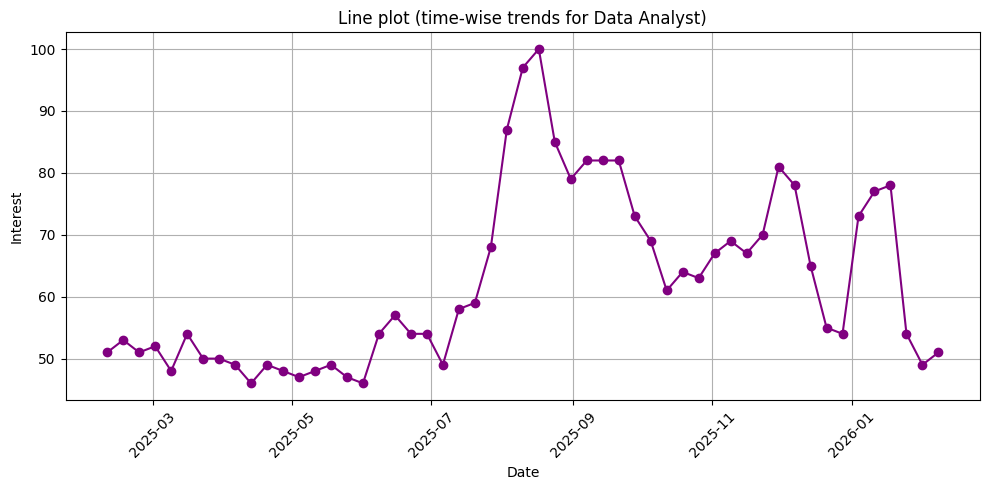

In [57]:
plt.figure(figsize=(10,5))
plt.plot(overtime.index, overtime[keywords], marker='o', color='purple')
plt.title("Line plot (time-wise trends for Data Analyst)")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Compare Multiple Keywords(Line Plot of All 3 Keywords)


In [ ]:
keywords = ["Data Analyst", "Data Science", "AIML"]
pytrends.build_payload(keywords,cat=0, timeframe='today 12-m', geo='', gprop='')

- Comparison on Google Trends

c:\Users\Divya\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


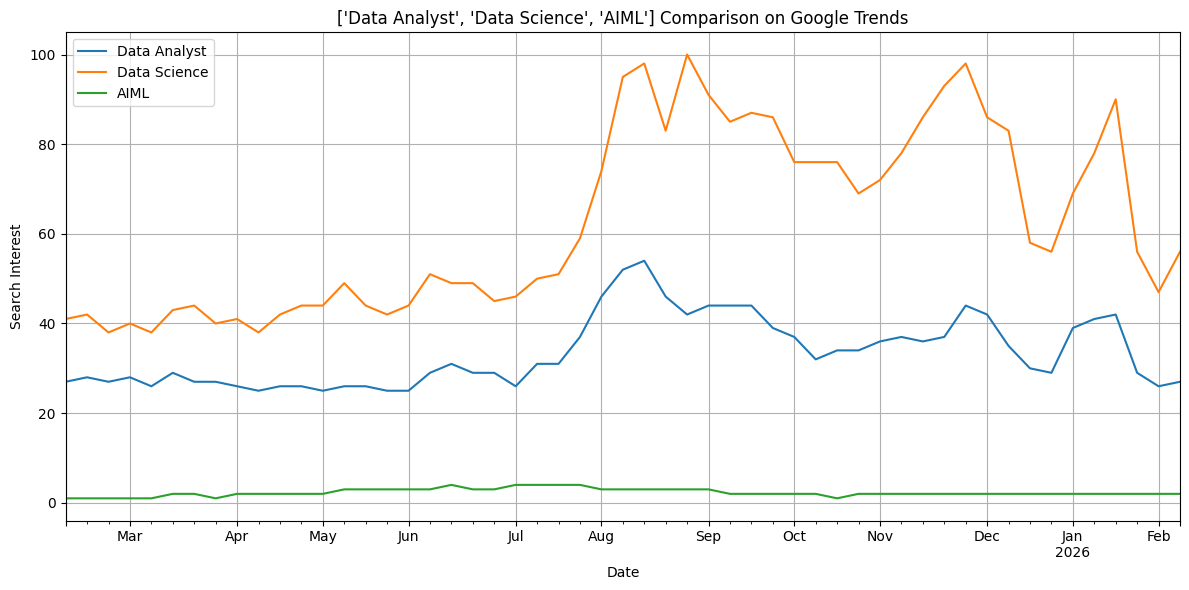

In [ ]:
compare_data = pytrends.interest_over_time()
compare_data.drop(columns=['isPartial'], inplace=True)

compare_data.plot(figsize=(12,6))
plt.title(f"{keywords} Comparison on Google Trends")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Country-wise interest Deduction

In [60]:
pytrends = TrendReq(hl='en-US',tz=360)         # tz=330 for India
keywords = ["Data Analyst"]


pytrends.build_payload(kw_list=keywords, cat=0, timeframe='today 12-m', geo='', gprop='')

In [61]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by=keywords, ascending=False).head(10)

- Making a Bar Plot for Top Countries

C:\Users\Divya\AppData\Local\Temp\ipykernel_31264\965055199.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


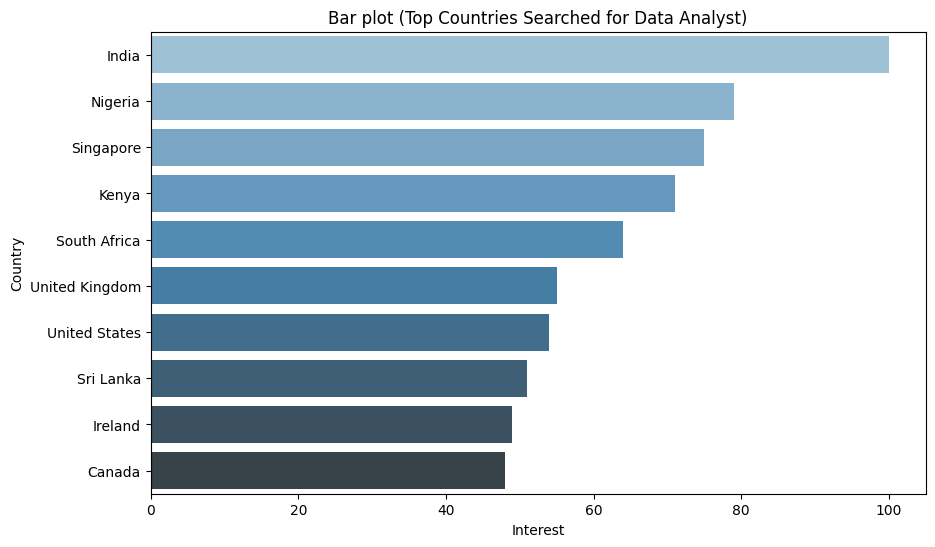

In [62]:
cb = region_data.reset_index()
cb.columns = ['Country', 'Interest']

plt.figure(figsize=(10,6))

sns.barplot(
    data=cb,
    x='Interest',
    y='Country',
    palette='Blues_d'
)

plt.title("Bar plot (Top Countries Searched for Data Analyst)")
plt.xlabel("Interest")
plt.ylabel("Country")
plt.show()